# Load Data and Explore

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import yfinance as yf
from sklearn.linear_model import LinearRegression
from datetime import timedelta
import scipy.stats as stats
from datetime import datetime
import calendar

In [2]:
fund_df = pd.read_excel('../data/cr/Colrain_Daily_Performance.xlsx', sheet_name='Gross Performance')

In [3]:
fund_df.head()

,START DATE,END DATE,TWR GROSS
0,2026-05-13,2026-05-14,-0.013868
1,2026-05-12,2026-05-13,0.010431
2,2026-05-11,2026-05-12,-0.013919
3,2026-05-10,2026-05-11,0.043800
4,2026-05-06,2026-05-10,-0.017950


In [4]:
fund_df["START DATE"] = pd.to_datetime(fund_df["START DATE"])
fund_df["END DATE"] = pd.to_datetime(fund_df["END DATE"])
fund_df = fund_df.sort_values(by="END DATE").reset_index(drop=True)

In [5]:
fund_df.head()

,START DATE,END DATE,TWR GROSS
0,2022-02-09,2022-02-10,0.000000
1,2022-02-10,2022-02-14,0.011344
2,2022-02-14,2022-02-15,0.004129
3,2022-02-15,2022-02-16,0.000719
4,2022-02-16,2022-02-17,-0.007873


# Define Functions

In [6]:
def fetch_market_data(
    start_date: pd.Timestamp, end_date: pd.Timestamp
) -> pd.DataFrame:
    """Fetches S&P 500 historical daily close prices via yfinance and calculates

    daily log/simple returns.
    """
    # Pad the download window slightly to handle edge cases/time-zones
    download_start = (start_date - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
    download_end = (end_date + pd.Timedelta(days=5)).strftime("%Y-%m-%d")

    # Download ^GSPC (S&P 500 Index)
    sp500 = yf.download(
        "^GSPC", start=download_start, end=download_end, progress=False
    )

    # Calculate daily simple returns based on Adjusted Close
    sp500["MKT_DAILY_RETURN"] = sp500["Close"].pct_change()
    return sp500[["MKT_DAILY_RETURN"]].dropna()

In [7]:
def align_market_returns(
    fund_df: pd.DataFrame, market_df: pd.DataFrame
) -> pd.DataFrame:
    """Geometrically compounds daily S&P 500 returns to match the exact start-and-end

    date windows of the fund data, ensuring mathematically rigorous alignment.
    """
    mkt_returns_aligned = []

    for _, row in fund_df.iterrows():
        start = row["START DATE"]
        end = row["END DATE"]

        # Filter market trading days falling inside the fund's specific pricing window
        mask = (market_df.index > start) & (market_df.index <= end)
        period_mkt_data = market_df.loc[mask, "MKT_DAILY_RETURN"]

        if len(period_mkt_data) > 0:
            # Geometric compounding: (1 + r1) * (1 + r2) ... - 1
            comp_return = np.prod(1 + period_mkt_data) - 1
        else:
            # Fallback to zero if market was closed/no data exists for the stretch
            comp_return = 0.0

        mkt_returns_aligned.append(comp_return)

    fund_df["MARKET_RETURN"] = mkt_returns_aligned
    return fund_df

In [8]:
def calculate_beta(df: pd.DataFrame) -> float:
    """Calculates the systematic risk coefficient (Beta) of the portfolio

    relative to the market benchmark.
    """
    fund_ret = df["TWR GROSS"].values
    mkt_ret = df["MARKET_RETURN"].values

    # Generate the covariance matrix
    covariance_matrix = np.cov(fund_ret, mkt_ret)

    # Beta = Cov(Asset, Market) / Var(Market)
    covariance = covariance_matrix[0, 1]
    market_variance = covariance_matrix[1, 1]

    beta = covariance / market_variance
    return float(beta)

In [9]:
def calculate_beta_with_linregress(df: pd.DataFrame) -> dict:

    x = df["MARKET_RETURN"].values
    y = df["TWR GROSS"].values

    ##  y = slope * x + intercept
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    regression_results = {
        "Beta (Slope)": slope,
        "Alpha (Intercept)": intercept,
        "R-squared": r_value**2,
        "p-value": p_value,
        "Standard Error": std_err,
    }
    return regression_results

In [10]:

def plot_cumulative_returns(df: pd.DataFrame):
    """Calculates cumulative returns (wealth index starting at 1.0) for both

    the Fund and S&P 500, and plots them using plotly.express.
    """
    plot_df = df[["END DATE", "TWR GROSS", "MARKET_RETURN"]].copy()

    # (1 + r1) * (1 + r2) ...
    plot_df["Fund (TWR Gross)"] = (1 + plot_df["TWR GROSS"]).cumprod()
    plot_df["S&P 500 Benchmark"] = (1 + plot_df["MARKET_RETURN"]).cumprod()

    initial_row = pd.DataFrame(
        {
            "END DATE": [df["START DATE"].min()],
            "Fund (TWR Gross)": [1.0],
            "S&P 500 Benchmark": [1.0],
        }
    )
    plot_df = pd.concat([initial_row, plot_df], ignore_index=True)

    melted_df = plot_df.melt(
        id_vars=["END DATE"],
        value_vars=["Fund (TWR Gross)", "S&P 500 Benchmark"],
        var_name="Asset Class",
        value_name="Cumulative Performance (NAV)",
    )


    fig = px.line(
        melted_df,
        x="END DATE",
        y="Cumulative Performance (NAV)",
        color="Asset Class",
        title="<b>Portfolio Growth Comparison vs S&P 500</b>",
        labels={"END DATE": "Date Timeline", "Cumulative Performance (NAV)": "Growth of $1.00"},
        template="plotly_dark", 
    )


    fig.update_layout(
        title_x=0.5, 
        hovermode="x unified",  
        legend=dict(
            yanchor="top", y=0.99, xanchor="left", x=0.01
        ), 
    )

    fig.show()

# Run Analysis

/tmp/ipykernel_1106092/4118715701.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download(



                 PORTFOLIO RISK FACTOR REPORT
Analysis Period   : 2022-02-09 to 2026-05-14
Benchmark Profile : S&P 500 Index (^GSPC)
Aligned Data Points: 734 periods
------------------------------------------------------------
Portfolio BETA    : 0.0419

             ADVANCED LINEAR REGRESSION PERFORMANCE REPORT
Analysis Window    : 2022-02-09 to 2026-05-14
Portfolio BETA     : 0.0419
Portfolio ALPHA    : 0.0013 (Intercept return)
R-squared (R²)     : 0.0016 (0.2% explained by market)
p-value            : 2.8180e-01
Standard Error     : 0.0389
Generating interactive Plotly visual charts...


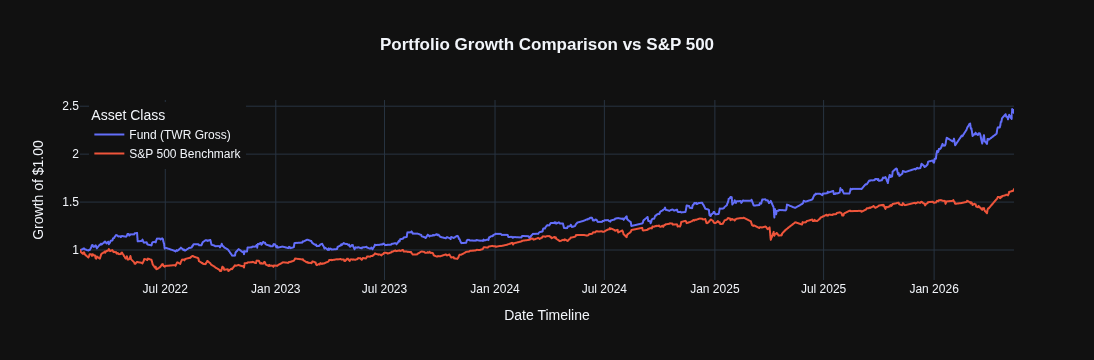

In [11]:
    min_date = fund_df["START DATE"].min()
    max_date = fund_df["END DATE"].max()

    # 2. Pipeline: Benchmark Data Pull
    print(
        f"Downloading S&P 500 (^GSPC) data from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}..."
    )
    market_df = fetch_market_data(min_date, max_date)

    # 3. Pipeline: Return Matrix Alignment
    aligned_df = align_market_returns(fund_df, market_df)

    # 4. Pipeline: Risk Metrics Engine
    portfolio_beta = calculate_beta(aligned_df)

    stats_results = calculate_beta_with_linregress(aligned_df)

    # 5. Pipeline: Reporting Engine
    print("\n" + "=" * 60)
    print("                 PORTFOLIO RISK FACTOR REPORT")
    print("=" * 60)
    print(
        f"Analysis Period   : {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}"
    )
    print(f"Benchmark Profile : S&P 500 Index (^GSPC)")
    print(f"Aligned Data Points: {len(aligned_df)} periods")
    print("-" * 60)
    print(f"Portfolio BETA    : {portfolio_beta:.4f}")
    print("=" * 60)

    print("\n" + "=" * 65)
    print("             ADVANCED LINEAR REGRESSION PERFORMANCE REPORT")
    print("=" * 65)
    print(f"Analysis Window    : {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
    print(f"Portfolio BETA     : {stats_results['Beta (Slope)']:.4f}")
    print(f"Portfolio ALPHA    : {stats_results['Alpha (Intercept)']:.4f} (Intercept return)")
    print(f"R-squared (R²)     : {stats_results['R-squared']:.4f} ({stats_results['R-squared']*100:.1f}% explained by market)")
    print(f"p-value            : {stats_results['p-value']:.4e}")
    print(f"Standard Error     : {stats_results['Standard Error']:.4f}")
    print("=" * 65)
    
    print("Generating interactive Plotly visual charts...")
    plot_cumulative_returns(aligned_df)